# Goal: Build your own implementation of logistic regression in Jax with a sparsity penalty and interaction terms

In the steps that follow, you will first build a basic version of logistic regression using gradient descent.  You will then add a sparsity penalty to the features that can be either an l1 or an l2 penalty; a flag for adding interaction terms to the feature set and model; and an interactions_penalty parameter that lets you set the penalty weight on just the interaction terms.

## Start a util.py file to house useful functions you've written in past projects

Put your print_model_evaluation and your plot_model_weights from project 1 into util.py and import it here so you can use it to analyze your models.  You will need to modify how the output of predict_probas is used depending on whether the model you pass in returns a 1-d array with probabilities of class 1 only, or a 2-d array with probabilities for both classes (this is the only thing your function can currently handle).

## Generate a toy dataset for a logistic regression model

Generate a feature matrix with N=250 instances, and D=10 feature dimensions.  The features should be randomly generated from a Gaussian with mean 0 and variance 1.  Consider using numpy's random.normal function.

Next generate a Dx1 vector of weights from a Gaussian with mean 0 and variance 10.

Generate probabilities for each label using these weights by taking the dot product of the features and the weights, then passing it through a sigmoid.  Use numpy's dot function, and the supplied sigmoid function below.

Generate an array of binary class labels by assigning y[ i ] = 1 for all instances where y_proba[ i ] > 0.5, and y[ i ] = 0 otherwise.  You should not use a for loop to do this.  Instead use boolean array indexing (https://numpy.org/doc/stable/user/basics.indexing.html)

Finally, generate a list of strings corresponding to the name for each feature.  You can call them whatever you want, but I recommend "Random Feature 1", "Random Feature 2" etc.

In [1]:
import numpy as np

def sigmoid(z):
    return 1/(1 + np.exp(-z))

N = 250 # number of instances
D = 10 # number of features

# feature matrix with a shape of (N,D) w/ Gauassian mean=0 and variance=1.
x = np.random.normal(loc=0, scale=1, size=(N,D))

# D-dimensional weight vector w/ Gaussian mean=0 and variance=10
weights = np.random.normal(loc=0, scale=np.sqrt(10), size=(D,1))

# probabilities for each label by finding the dot product of the features and weights and using sigmoid
probabilities = sigmoid(np.dot(x, weights)).flatten()

# generating an array of binary class labels 
y = (probabilities > 0.5).astype(int)

# generating list of strings corresponding the name for each feature
feature_names = [f"Random Feature {i+1}" for i in range(D)]

x, weights.flatten(), probabilities, y, feature_names

(array([[-0.9185309 ,  0.4125888 ,  0.1036127 , ...,  0.62472281,
          0.95878093,  0.68343381],
        [ 1.35310357,  0.75067378, -0.25151229, ..., -0.86698141,
          1.8241465 , -0.08994718],
        [ 1.36285033, -0.74584549, -1.37946871, ..., -0.62300813,
         -0.39684058, -0.22794587],
        ...,
        [ 0.14679501, -0.3288272 , -0.29217543, ...,  1.61714111,
         -1.27978372,  0.03559923],
        [-0.55418363, -0.63940933, -0.26615798, ..., -0.67575702,
          1.42105369,  1.43627606],
        [-0.26007288, -0.50588957,  0.40458068, ..., -1.27130278,
          0.81857426,  0.66603004]]),
 array([ 0.98250738, -4.67306557,  1.80411049,  0.3114494 , -3.94690708,
        -3.58079955, -0.24567743, -4.58221868,  0.53013322,  1.05114811]),
 array([5.72558968e-02, 9.99879735e-01, 9.98229938e-01, 1.20234236e-05,
        9.99895330e-01, 2.34126568e-06, 1.06954070e-02, 9.98848213e-01,
        2.38205057e-02, 7.81152003e-07, 9.99999997e-01, 8.55203495e-01,
        1

## Practice preprocessing data 

Generate 3 sets of indices corresponding to the train, valid and test sets.  The train set should be 60% of the data, the valid set should be 20% of the data and the test set should also be 20% of the data.  These sets should be random and shouldn't overlap.  Generate them by using scikit-learn's train_test_split function twice -- first to split out the test set, then to split the remaining indices into the train and valid set.  

Then scale the data using scikit-learn's StandardScaler.  You should fit the scaler on the train set only, then scale all of the data using it.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# generating random data(using data from previous dataset)
x = np.random.normal(0, 1, (250,10))
y = (np.random.rand(250) > 0.5).astype(int)

# split data(train data to 60% and test data to 20%)
x_temp_train, x_test, y_temp_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)

# split data into train(60%) and valid(20%) set
x_train, x_val, y_train, y_val = train_test_split(x_temp_train, y_temp_train, test_size=0.25, random_state=7) # 0.25 * 0.8 = 0.20(20%)

#initializes StandardScaler as scaler
scaler = StandardScaler()

# fit scaler on train data then transform the train data
x_train_scaled = scaler.fit_transform(x_train)

# transform val and test data
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

#output
x_train_scaled.shape, x_val_scaled.shape, x_test_scaled.shape


((150, 10), (50, 10), (50, 10))

## Write your own logistic regression implementation

Complete all of the methods that aren't labeled as STEP 2, STEP 3, or STEP 4 in logistic_regression.py (e.g. don't write the sparsity_loss method yet).  You are writing the core implementation of logistic regression without sparsity penalty and without interaction terms.

## Validate that your implementation works by comparing it to scikit-learn's implementation

Fit a scikit-learn implementation of logistic regression and your own implementation of logistic regression on the data you generated.  For both models, set penalty=None.  Compare their performance metrics and learned weights using the 2 functions in util.py.  These should be very similar, although they probably won't be exactly identical due to optimization error.  Note that scale doesn't matter for the weights, so just look at the shapes of the bar charts.  

Evaluation of scikit-learn Logistic Regression:
Fraction of positive labels in train set: 0.49
Fraction of positive labels in test set: 0.48
Train Accuracy: 0.59
Test Accuracy: 0.56
Train AUC: 0.64
Test AUC: 0.60
Evaluation of My Logistic Regression:
Fraction of positive labels in train set: 0.49
Fraction of positive labels in test set: 0.48
Train Accuracy: 0.49
Test Accuracy: 0.48
Train AUC: 0.64
Test AUC: 0.59


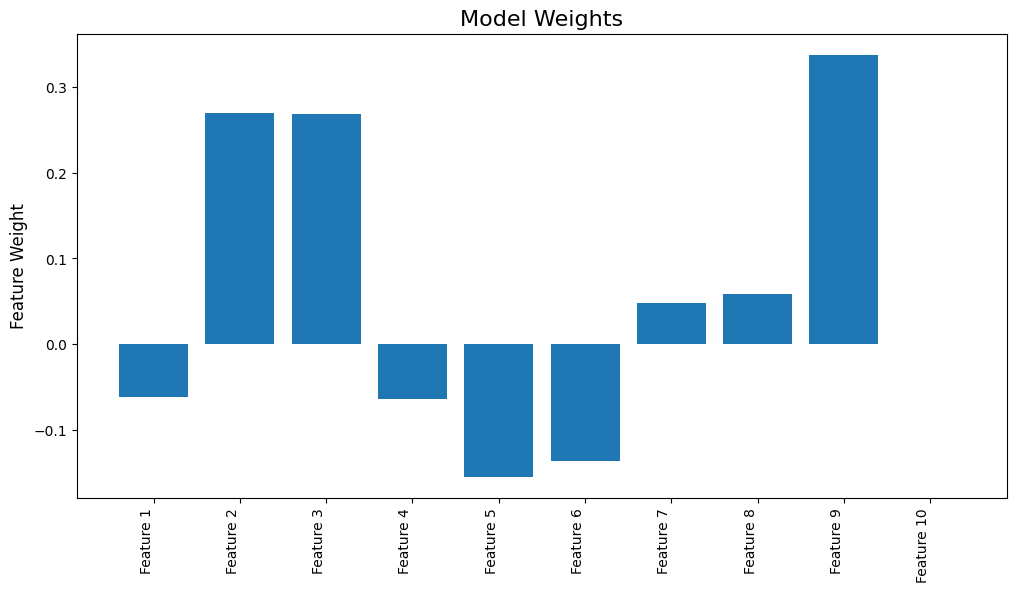

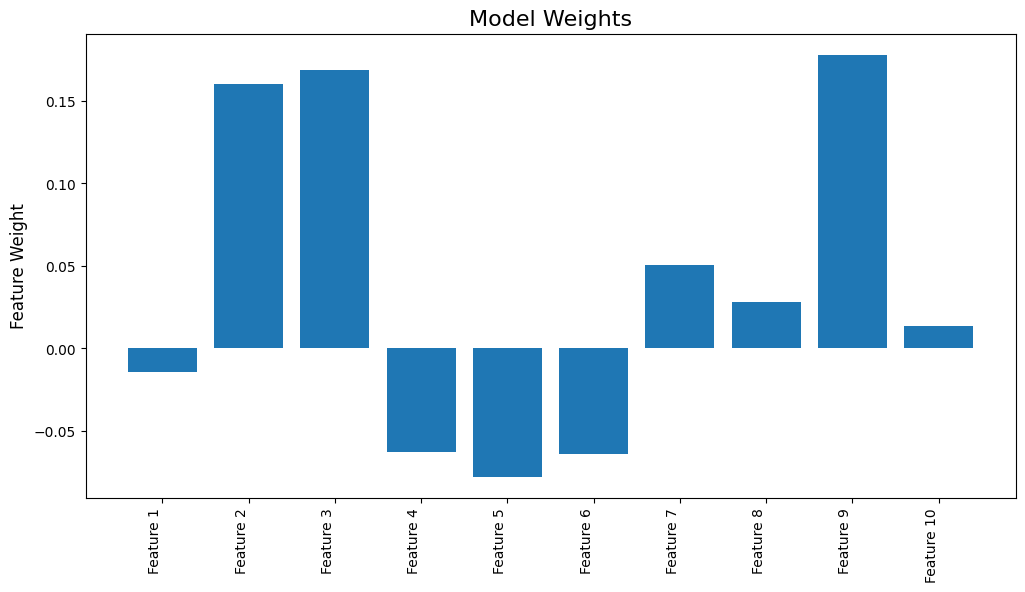

In [3]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from util import print_model_evaluation, plot_model_weights
from logistic_regression import LogisticRegression

# Fitting scikit-learn's LogisticRegression
sklearn_model = SklearnLogisticRegression(penalty=None, solver = 'lbfgs', max_iter=5000)
sklearn_model.fit(x_train_scaled, y_train)

# Fitting my own logistic regression model
my_model = LogisticRegression(feature_names=["Feature " + str(i) for i in range(1, 11)], n_iter=5000)
my_model.fit(x_train_scaled, y_train)


# evaluating scikit-learn model and my model
print("Evaluation of scikit-learn Logistic Regression:")
print_model_evaluation(sklearn_model, x_train_scaled, y_train, x_test_scaled, y_test)

print("Evaluation of My Logistic Regression:")
print_model_evaluation(my_model, x_train_scaled, y_train, x_test_scaled, y_test)

# plot weights for scikit-learn model and my model
plot_model_weights(sklearn_model, feature_names=["Feature " + str(i) for i in range(1, 11)])
plot_model_weights(my_model, feature_names=["Feature " + str(i) for i in range(1,11)])


## Step 2: Add an l1 sparsity penalty 

Complete all of the methods labeled STEP 2 in logistic_regression.py.  Update the other methods where comments with STEP 2 give additional instructions.  You are adding a sparsity penalty to the weights of your model.

## Test step 2: Validate that your l1 penalty implementation works

Fit your own implementation of logistic regression with an l1 penalty and increasing values of alpha.  Show that as the penalty gets stronger, the model gets sparser.  You're trying to find a value for alpha where only a few of the feature weights are showing up as having weights that aren't very close to the zero line in the graph.  You should use your plot_model_weights function to show this.

In [7]:
alphas = [0.01, 1, 10, 100, 1000] #values of alpha are increasing

for alpha in alphas:
    print(f"Training model with alpha = {alphas}")
    
    # fitting l1 penalty into logistic regression model
    my_model = LogisticRegression(feature_names=["Feature " + str(i) for i in range(1, 11)], penalty='l1', alpha=alpha, n_iter=5000)
    
    my_model.fit(x_train_scaled, y_train)
    
    #plot weights
    plot_model_weights(my_model, feature_names=["Feature " + str(i) for i in range(1, 11)])

Training model with alpha = [0.01, 1, 10, 100, 1000]


TypeError: Using a non-tuple sequence for multidimensional indexing is not allowed; use `arr[array(seq)]` instead of `arr[seq]`. See https://github.com/google/jax/issues/4564 for more information.

## Step 3: Add interaction terms to your model.

Complete all of the methods labeled STEP 3 in logistic_regression.py.  Update the other methods where comments with STEP 3 give additional instructions.  You are adding interaction terms to your model.

## Test step 3: Train your model and check that the interaction terms are in the feature visualization

Fit your own implementation of logistic regression with no penalty and with interaction terms.  The interaction terms should show up in the weights visualization, and the model performance shouldn't be worse.


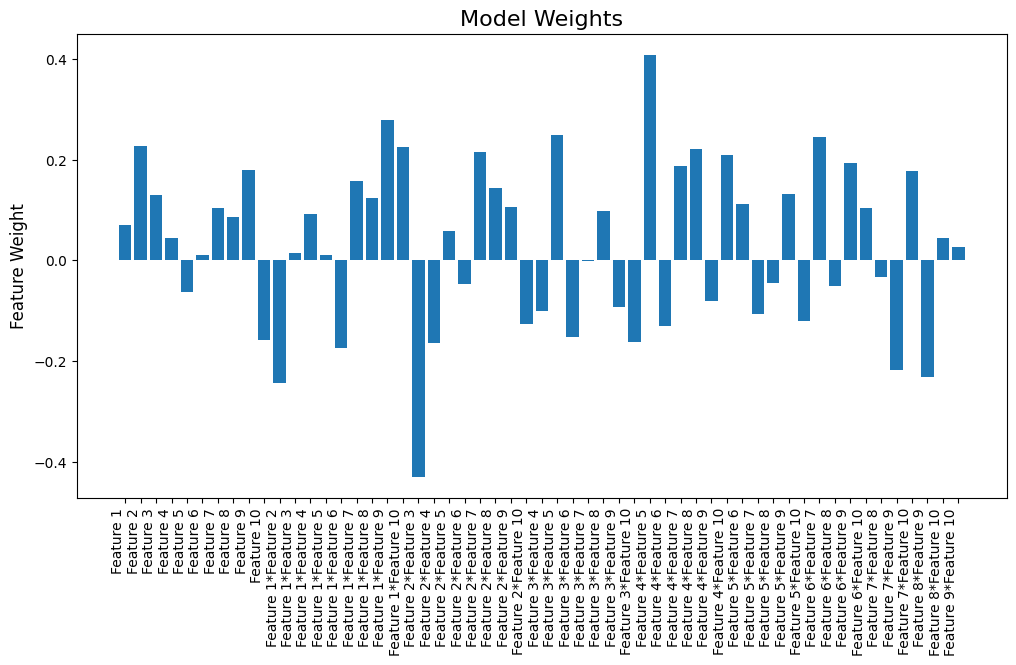

Evaluation of My Logistic Regression with Interaction Terms:
Fraction of positive labels in train set: 0.49
Fraction of positive labels in test set: 0.48
Train Accuracy: 0.50
Test Accuracy: 0.46
Train AUC: 0.79
Test AUC: 0.59


In [5]:
from logistic_regression import LogisticRegression
from util import plot_model_weights
import itertools

# Generating original feature names
original_feature_names = ["Feature " + str(i) for i in range(1, 11)]

# Generating interaction feature names
interaction_feature_names = original_feature_names + [f"{i}*{j}" for i, j in itertools.combinations(original_feature_names, 2)]

# Initializing the model with interaction terms
my_model = LogisticRegression(feature_names=original_feature_names, penalty=None, interactions=True, n_iter=5000, scale=False)

# Fitting the model
my_model.fit(x_train_scaled, y_train)

# Plotting model weights, using both original and interaction feature names
plot_model_weights(my_model, feature_names=interaction_feature_names)

# Evaluating the model 
print("Evaluation of My Logistic Regression with Interaction Terms:")
print_model_evaluation(my_model, x_train_scaled, y_train, x_test_scaled, y_test)

## Step 4: Add a separate penalty for just the interaction terms

Complete all of the methods labeled STEP 4 in logistic_regression.py.  Update the other methods where comments with STEP 4 give additional instructions.  You are adding a separate sparsity penalty that can be applied to just the interaction terms.

## Test step 4: Train your model with a high interaction-penalty and check that the interaction terms get zeroed out

Fit your own implementation of logistic regression with no penalty on any terms except the interaction terms.  Put a high penalty on the interaction terms (you can try 1.).  Your graph of the feature weights should show that, for some setting of the interaction terms penalty, all of the interaction terms get zeroed out.  You shouldn't see this for the features that aren't interaction terms.

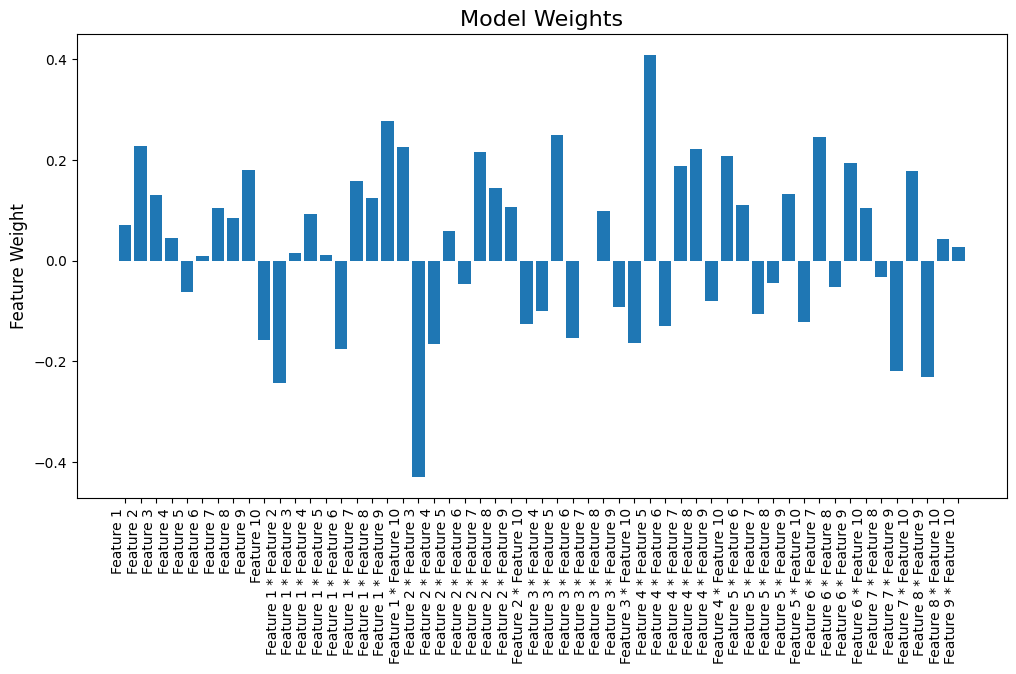

Evaluation of Logistic Regression with High Interaction Penalty:
Fraction of positive labels in train set: 0.49
Fraction of positive labels in test set: 0.48
Train Accuracy: 0.50
Test Accuracy: 0.46
Train AUC: 0.79
Test AUC: 0.59


In [6]:
from logistic_regression import LogisticRegression
from util import plot_model_weights, print_model_evaluation

#Training model with a high interaction penalty and no penalty for original features
my_model = LogisticRegression(
    feature_names=["Feature " + str(i) for i in range(1, 11)],  # Features
    penalty=None,      # No penalty on original terms
    interactions=True, # Include interaction terms
    n_iter=5000,       # Number of iterations
    alpha=0.,          # No penalty on original features
    interaction_alpha=20.0,  # High penalty for interaction terms
    scale=False        # Do not scale preprocessed data
)

# Fitting model with training data
my_model.fit(x_train_scaled, y_train)

# Generating extended feature names w/ including interaction terms
original_feature_names = ["Feature " + str(i) for i in range(1, 11)]
interaction_feature_names = [f"Feature {i} * Feature {j}" for i in range(1, 11) for j in range(i + 1, 11)]
extended_feature_names = original_feature_names + interaction_feature_names

# plotting weights
plot_model_weights(my_model, feature_names=extended_feature_names)

# Evaluating model
print("Evaluation of Logistic Regression with High Interaction Penalty:")
print_model_evaluation(my_model, x_train_scaled, y_train, x_test_scaled, y_test)